# Explicación complemento SVM en clasificación

**Autor:** Jazna Meza Hidalgo

**Correo Electrónico:** ja.meza@profesor.duoc.cl

**Fecha de Creación:** Mayo de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook ofrece la explicación de los conceptos relacionados con el funcionamiento de SVM como clasificador.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from matplotlib.animation import FuncAnimation
from sklearn.datasets import make_blobs
from IPython.display import HTML

In [ ]:
# Dataset artificial binario
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    random_state=29)

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=29,
                                                    stratify=y)

In [ ]:
X_train.shape

(75, 2)

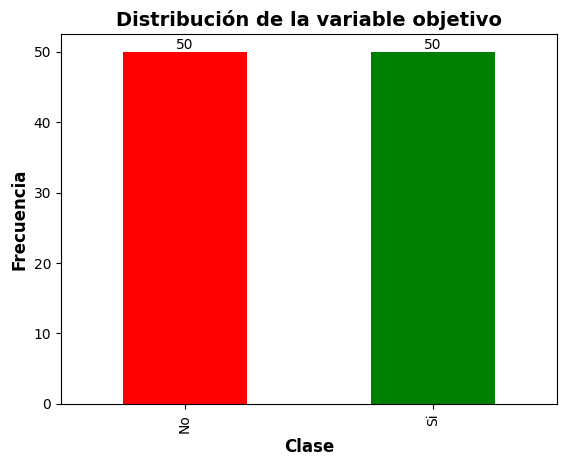

In [ ]:
# Grafica la distribución de la variable objetivo
pd.Series(y).value_counts().plot(kind="bar", color=["red", "green"])
plt.title("Distribución de la variable objetivo", fontweight="bold", fontsize=14)
plt.xlabel("Clase", fontweight="bold", fontsize=12)
plt.ylabel("Frecuencia", fontweight="bold", fontsize=12)
# Agrega los nombres de las clases en el eje (0 = No, 1 = Si)
plt.xticks([0, 1], ["No", "Si"])
# Agrega las etiquetas a cada clase
for i, count in enumerate(pd.Series(y).value_counts()):
    plt.text(i, count, str(count), ha='center', va='bottom')
plt.show()

# Concepto de hiperplano

In [ ]:
# Figura
fig, ax = plt.subplots(figsize=(7, 6))

# Ejes
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)

ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

# Datos x
x = np.linspace(-10, 10, 200)

# Línea inicial
linea, = ax.plot([], [], lw=3)

# Texto
texto = ax.text(
    0.02,
    0.95,
    '',
    transform=ax.transAxes,
    fontsize=14
)

# Valores de m
m_vals = np.linspace(-3, 3, 120)

# Valores de b
b_vals = np.linspace(-3, 3, 120)
# Animación
def update(frame):

    b = b_vals[frame]
    m = m_vals[frame]
    #b = 0

    y = m*x + b

    linea.set_data(x, y)

    texto.set_text(f"y = {m:.2f}x + {b}")

    return linea, texto

animacion = FuncAnimation(
    fig,
    update,
    frames=len(m_vals),
    interval=80
)

plt.close()

HTML(animacion.to_jshtml())

**¿Qué hace realmente un SVM?**

No solo separa clases.

Busca el hiperplano que separa correctamente y deja el mayor margen posible.

Es decir, los puntos quedan lo más lejos posible de la frontera.

Matemáticamente, el hiperplano de un SVM se escribe:

$w^Tx+b=0$

donde:

+ w → vector normal al hiperplano
+ b → sesgo/intercepto
+ x → punto

# `Probability=False`

In [ ]:
modelo = SVC(probability=False)
modelo.fit(X_train, y_train)

SVC()

In [ ]:
modelo.predict(X_test[:3])

array([0, 1, 1])

# `Probability=True`

In [ ]:
modelo = SVC(probability=True)
modelo.fit(X_train, y_train)

SVC(probability=True)

In [ ]:
modelo.predict_proba(X_test[:3])

array([[0.80596593, 0.19403407],
       [0.29940331, 0.70059669],
       [0.08051993, 0.91948007]])

In [ ]:
umbral = 0.9
y_proba = modelo.predict_proba(X_test[:3])
y_predicciones = (y_proba >= umbral)[:, 1]

In [ ]:
y_predicciones = y_predicciones.astype(int)
y_predicciones

array([0, 0, 1])

In [ ]:
modelo.predict(X_test[:3])

array([0, 1, 1])

Los SVM originalmente no generan probabilidades.

Un SVM realmente calcula una distancia al hiperplano:

$f(x)=w^Tx+b$

donde:

+ valores positivos → clase 1

+ valores negativos → clase 0

+ magnitud indica qué tan lejos está del hiperplano.

Cuando probability=True, sklearn aplica un método adicional llamado `Platt Scaling`

Este método transforma esas distancias en probabilidades usando una función sigmoide:

$P(y=1∣x)=\frac{1}{1 + e^{Af(x)+B}}$
	​


Los parámetros A y B se aprenden automáticamente.

In [ ]:
modelo.decision_function(X_test[:3])

array([-0.59986865,  0.34778003,  1.00759512])

In [ ]:
# Dataset
X, y = make_blobs(
    n_samples=50,
    centers=2,
    random_state=29,
    cluster_std=1.2
)

# Modelo SVM
modelo = SVC(kernel="linear")
modelo.fit(X, y)

# Figura
fig, ax = plt.subplots(figsize=(7, 6))

# Dibujar puntos
ax.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")

# Dibujar support vectors
ax.scatter(
    modelo.support_vectors_[:,0],
    modelo.support_vectors_[:,1],
    s=120,
    facecolors='none',
    edgecolors='k'
)

# Crear malla
xx = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
yy = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100)

XX, YY = np.meshgrid(xx, yy)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = modelo.decision_function(xy).reshape(XX.shape)

# Hiperplano y márgenes
ax.contour(
    XX,
    YY,
    Z,
    levels=[-1, 0, 1],
    linestyles=['--', '-', '--'],
    colors='black'
)

# Punto móvil
punto, = ax.plot([], [], 'go', markersize=12)

texto = ax.text(
    0.02,
    0.95,
    '',
    transform=ax.transAxes,
    fontsize=12
)

# Trayectoria
x_vals = np.linspace(
    X[:,0].min()-1,
    X[:,0].max()+1,
    100
)

y_const = np.mean(X[:,1])

# Animación
def update(frame):

    x = x_vals[frame]
    y = y_const

    punto.set_data([x], [y])

    distancia = modelo.decision_function([[x, y]])[0]

    texto.set_text(
        f"Distancia al hiperplano: {distancia:.2f}"
    )

    return punto, texto

animacion = FuncAnimation(
    fig,
    update,
    frames=len(x_vals),
    interval=100
)

plt.close()

HTML(animacion.to_jshtml())

# Efecto del parámetro `C`

In [ ]:
X, y = make_blobs(
    n_samples=80,
    centers=2,
    cluster_std=1.3,
    random_state=29
)

# Valores de C
C_values = np.logspace(-2, 2, 80)

fig, ax = plt.subplots(figsize=(8, 6))

x_min, x_max = X[:, 0].min() - 2, X[:, 0].max() + 2
y_min, y_max = X[:, 1].min() - 2, X[:, 1].max() + 2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

def update(frame):

    ax.clear()

    C = C_values[frame]

    # Modelo SVM
    modelo = SVC(kernel="linear",C=C)

    modelo.fit(X, y)

    # Predicción sobre la malla
    Z = modelo.decision_function(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    # Puntos
    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap="coolwarm",
        s=50
    )

    # Support vectors
    ax.scatter(
        modelo.support_vectors_[:, 0],
        modelo.support_vectors_[:, 1],
        s=180,
        facecolors='none',
        edgecolors='black',
        linewidths=2,
        label="Support Vectors"
    )

    # Hiperplano y márgenes
    ax.contour(
        xx,
        yy,
        Z,
        levels=[-1, 0, 1],
        linestyles=['--', '-', '--'],
        colors='black'
    )

    # Título
    ax.set_title(
        f"SVM lineal — Efecto de C = {C:.4f}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.legend(loc="upper right")

    # Explicación visual
    if C < 0.3:
        texto = "C pequeño → margen más amplio, más tolerancia a errores"
    elif C < 10:
        texto = "C intermedio → equilibrio"
    else:
        texto = "C grande → margen estrecho, penaliza más los errores"

    ax.text(
        0.02,
        0.02,
        texto,
        transform=ax.transAxes,
        fontsize=11,
        bbox=dict(facecolor='white', alpha=0.8)
    )

# Crear animación
animacion = FuncAnimation(
    fig,
    update,
    frames=len(C_values),
    interval=180
)

plt.close()


# Muestra la animación
HTML(animacion.to_jshtml())

Cuando C es pequeño, **C tiende a 0**

+ margen amplio
+ mayor tolerancia a errores
+ modelo más flexible con errores
+ posible underfitting

Cuando C es grande, **C tiende a $∞$**

+ margen estrecho
+ intenta clasificar perfectamente
+ más sensible a outliers
+ posible overfitting

In [ ]:
X, y = make_blobs(
    n_samples=80,
    centers=2,
    cluster_std=1.3,
    random_state=29
)

# Valores de C
C_values = np.logspace(-2, 2, 80)

fig, ax = plt.subplots(figsize=(8, 6))

x_min, x_max = X[:, 0].min() - 2, X[:, 0].max() + 2
y_min, y_max = X[:, 1].min() - 2, X[:, 1].max() + 2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

def update(frame):

    ax.clear()

    C = C_values[frame]

    # Modelo SVM
    modelo = SVC(kernel="rbf",C=C)

    modelo.fit(X, y)

    # Predicción sobre la malla
    Z = modelo.decision_function(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    # Puntos
    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap="coolwarm",
        s=50
    )

    # Support vectors
    ax.scatter(
        modelo.support_vectors_[:, 0],
        modelo.support_vectors_[:, 1],
        s=180,
        facecolors='none',
        edgecolors='black',
        linewidths=2,
        label="Support Vectors"
    )

    # Hiperplano y márgenes
    ax.contour(
        xx,
        yy,
        Z,
        levels=[-1, 0, 1],
        linestyles=['--', '-', '--'],
        colors='black'
    )

    # Título
    ax.set_title(
        f"SVM kernel rbf — Efecto de C = {C:.4f}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.legend(loc="upper right")

    # Explicación visual
    if C < 0.3:
        texto = "C pequeño → margen más amplio, más tolerancia a errores"
    elif C < 10:
        texto = "C intermedio → equilibrio"
    else:
        texto = "C grande → margen estrecho, penaliza más los errores"

    ax.text(
        0.02,
        0.02,
        texto,
        transform=ax.transAxes,
        fontsize=11,
        bbox=dict(facecolor='white', alpha=0.8)
    )

# Crear animación
animacion = FuncAnimation(
    fig,
    update,
    frames=len(C_values),
    interval=180
)

plt.close()


# Muestra la animación
HTML(animacion.to_jshtml())